# Part 0: Data Download and Cleaning


##  Data download and Verification

We first establish a local directory structure to store the NYC Yellow Taxi Trip Records  and include a conditional check to download the January 2024 dataset from a cloud source only if it is not already present on our system. By using the polars library for high-performance data loading, we set up the necessary environment to begin. NOTE: TO USE A CUSTOM PRECLEANED PARQUET SKIP TO THE CELL JUST ABOVE PART 1

In [170]:
import polars as pl
import pathlib as pathlb
from sklearn.preprocessing import StandardScaler, OneHotEncoder

file_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
base_dir = pathlb.Path('data/raw')
file_name = 'yellow_tripdata_2024-01.parquet'
file_path = base_dir/file_name
clean_path ='data/raw/cleaned_data.parquet'

## Checks if file downloaded if not it downloads it
if not file_path.is_file() :
    base_dir.mkdir(parents=True, exist_ok=True)
    print(f" Error {file_name} not found downloading...\n")
    pl.read_parquet(file_url).write_parquet(file_path)
taxi_df = pl.read_parquet(file_path)



Next we verify our dataset's structure to ensure all necessary variables for Part 1 of the assignment are present. We define a target list of columns and check to identify any missing data 

In [171]:
cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime','trip_distance','PULocationID', 'DOLocationID','fare_amount','tip_amount','payment_type']

try:
    # taxi_df should already be defined as a Polars DataFrame
    missing_cols = set(cols) - set(taxi_df.columns)

    if missing_cols:
        print("Missing columns:", missing_cols)
    else:
        print("No missing columns.")
except Exception as e:
    print("Error while checking columns:", e)

print(f"{"SCHEMA"}\n")
print(f"{"Name":<25}Type")
for col, type in taxi_df.schema.items() :
    print(f"{col:<25}{type}")

No missing columns.
SCHEMA

Name                     Type
VendorID                 Int32
tpep_pickup_datetime     Datetime(time_unit='ns', time_zone=None)
tpep_dropoff_datetime    Datetime(time_unit='ns', time_zone=None)
passenger_count          Int64
trip_distance            Float64
RatecodeID               Int64
store_and_fwd_flag       String
PULocationID             Int32
DOLocationID             Int32
payment_type             Int64
fare_amount              Float64
extra                    Float64
mta_tax                  Float64
tip_amount               Float64
tolls_amount             Float64
improvement_surcharge    Float64
total_amount             Float64
congestion_surcharge     Float64
Airport_fee              Float64


## Data Cleaning


### Cleaning Taxi Parquet

In this section, we conduct data cleaning, by removing records with null/NaN values, eliminate trips with invalid distances, and times

In [172]:
taxi_df = taxi_df.filter(
    pl.all_horizontal(pl.col(cols).is_not_null()) &
    (~pl.col("fare_amount").is_nan()) & 
    (~pl.col("trip_distance").is_nan())
)
taxi_df = taxi_df.filter(pl.col('trip_distance') > 0)

taxi_df = taxi_df.filter((pl.col('fare_amount') > 0) & (pl.col('fare_amount') <= 500))

taxi_df = taxi_df.filter(pl.col('tpep_dropoff_datetime') > pl.col('tpep_pickup_datetime'))

taxi_df = taxi_df.filter(pl.col('tpep_pickup_datetime').dt.year() == 2024)

clean_path ='data/cleaned_data.parquet'

taxi_df.write_parquet(clean_path)


# Part 1: Data Preprocessing & Feature Engineering 


## Feature Engineering

In this section we use the cleaned dataset to generate features for the models we will be creating later

In [173]:
taxi_df = pl.read_parquet('data/cleaned_data.parquet')
display(taxi_df)

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,"""N""",186,79,2,17.7,1.0,0.5,0.0,0.0,1.0,22.7,2.5,0.0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2,2024-01-31 23:45:59,2024-01-31 23:54:36,null,3.18,null,null,107,263,0,15.77,0.0,0.5,2.0,0.0,1.0,21.77,null,null
1,2024-01-31 23:13:07,2024-01-31 23:27:52,null,4.0,null,null,114,236,0,18.4,1.0,0.5,2.34,0.0,1.0,25.74,null,null
2,2024-01-31 23:19:00,2024-01-31 23:38:00,null,3.33,null,null,211,25,0,19.97,0.0,0.5,0.0,0.0,1.0,23.97,null,null


First we join obatin the look up table 

In [174]:
file_name ='lookup.csv'
file_path = base_dir / file_name
file_url = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'

if not file_path.is_file():
    base_dir.mkdir(parents=True, exist_ok=True)
    print(f" Error {file_name} not found downloading...\n")
    pl.read_csv(file_url,encoding="utf8-lossy").write_csv(file_path)

Next we explore the lookup table

In [175]:
lookup_df = pl.read_csv(file_path)
display(lookup_df)

LocationID,Borough,Zone,service_zone
i64,str,str,str
1,"""EWR""","""Newark Airport""","""EWR"""
2,"""Queens""","""Jamaica Bay""","""Boro Zone"""
3,"""Bronx""","""Allerton/Pelham Gardens""","""Boro Zone"""
4,"""Manhattan""","""Alphabet City""","""Yellow Zone"""
5,"""Staten Island""","""Arden Heights""","""Boro Zone"""
…,…,…,…
261,"""Manhattan""","""World Trade Center""","""Yellow Zone"""
262,"""Manhattan""","""Yorkville East""","""Yellow Zone"""
263,"""Manhattan""","""Yorkville West""","""Yellow Zone"""


Now we check all the available Boroughs in the lookup dataframe

In [176]:
display(lookup_df.select(pl.col('Borough')).unique())

Borough
str
"""EWR"""
"""Staten Island"""
"""Queens"""
"""Bronx"""
"""N/A"""
"""Manhattan"""
"""Unknown"""
"""Brooklyn"""


Now we use the Borough names and join them to the associated pick up and drop off locations

In [177]:
# join pickup location to PULocationID
taxi_df = taxi_df.join(
    lookup_df.select(["LocationID", "Borough"]),
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
).rename({"Borough": "PU_Borough"})

#join dropoff location to DOLocationID
taxi_df = taxi_df.join(
    lookup_df.select(["LocationID", "Borough"]),
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
).rename({"Borough": "DO_Borough"})

# replace nulls with Unknown
taxi_df = taxi_df.with_columns([
    pl.col("PU_Borough").fill_null("Unknown"),
    pl.col("DO_Borough").fill_null("Unknown")
])


We add the temporal features; pickup_hour, pickup_day_of_week (numeric, 0 = Monday),is_weekend (boolean)

In [178]:
#Temporal features
taxi_df = taxi_df.with_columns( 
    #Create col that indexes pickup hour
    (pl.col('tpep_pickup_datetime').dt.hour().alias('pickup_hour')),
    #Create col that indexes weekday, starting at 0
    (pl.col('tpep_pickup_datetime').dt.weekday()-1).alias('pickup_day_of_week')
    ).with_columns(
        # Creates boolean weekend col
        (pl.col('pickup_day_of_week') >= 5).alias('is_weekend')
        .cast(pl.Int8)
    )


We add the trip features: trip_duration_minutes, trip_speed_mph, log_trip_distance (log-
transformed distance)

In [179]:
#Trip Features
taxi_df  = taxi_df.with_columns(
    (pl.col('tpep_dropoff_datetime')- pl.col('tpep_pickup_datetime'))
    #Convert trip duration minutes distance to interger
    .dt.total_minutes().alias('trip_duration_minutes')
    ).with_columns(
        #accounts for zero denominator error
        pl.when(pl.col('trip_duration_minutes') > 0)
        .then(pl.col('trip_distance')* 60/(pl.col('trip_duration_minutes')))
        .otherwise(0) #if duration 0 -> just 0 mph
        .alias('trip_speed_mph')
    ).with_columns(
    pl.col('trip_distance').log1p().alias('log_trip_distance'))

We addthe Fare features: fare_per_mile (fare_amount / trip_distance, handle division by zero),
fare_per_minute (fare_amount / trip_duration_minutes)

In [180]:
#Fare Features
taxi_df = taxi_df.with_columns(
        pl.when(pl.col('trip_distance') > 0)
        .then(pl.col('fare_amount')/(pl.col('trip_distance')))
        .otherwise(0) #if distance 0 -> just 0
        .alias('fare_per_mile'),
        pl.when(pl.col('trip_duration_minutes') > 0)
        .then(pl.col('fare_amount')/(pl.col('trip_duration_minutes')))
        .otherwise(0) #if distance 0 -> just 0
        .alias('fare_per_minute')
        )


Next we observe the schema after the newly added features

In [181]:
print(f"{"Name":<25}Type")
for col, type in taxi_df.schema.items() :
    print(f"{col:<25}{type}")


Name                     Type
VendorID                 Int32
tpep_pickup_datetime     Datetime(time_unit='ns', time_zone=None)
tpep_dropoff_datetime    Datetime(time_unit='ns', time_zone=None)
passenger_count          Int64
trip_distance            Float64
RatecodeID               Int64
store_and_fwd_flag       String
PULocationID             Int32
DOLocationID             Int32
payment_type             Int64
fare_amount              Float64
extra                    Float64
mta_tax                  Float64
tip_amount               Float64
tolls_amount             Float64
improvement_surcharge    Float64
total_amount             Float64
congestion_surcharge     Float64
Airport_fee              Float64
PU_Borough               String
DO_Borough               String
pickup_hour              Int8
pickup_day_of_week       Int8
is_weekend               Int8
trip_duration_minutes    Int64
trip_speed_mph           Float64
log_trip_distance        Float64
fare_per_mile            Float64
fare_p

We filter out all payments other than credit card payments as recommended

In [182]:
taxi_df = taxi_df.filter(pl.col("payment_type") == 1)

## Target Variable Creation 

Here we create our second target variable high_tip, using binary classification

In [183]:
taxi_df = taxi_df.with_columns([
    pl.col("tip_amount").cast(pl.Float64).alias("tip_amount"),
    (pl.col("tip_amount") > (pl.col("fare_amount") * 0.20))
    #casts the boolean value to 1 or zero
    .cast(pl.Int8)
    .alias("high_tip")
])


Next we explore the distribution of our second target variable high_tip

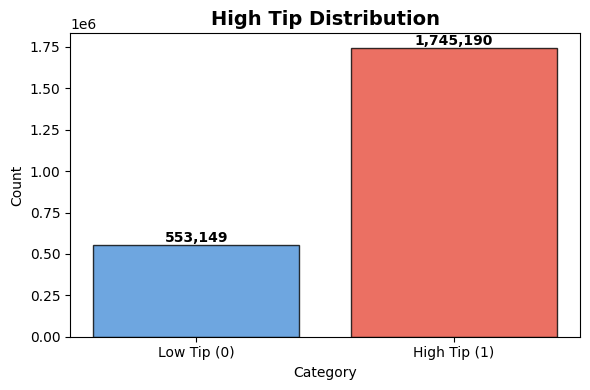

high_tip,count,proportions
i8,u32,f64
1,1745190,0.759327
0,553149,0.240673


In [184]:
import matplotlib.pyplot as plt


counts_df = (
    taxi_df.group_by("high_tip")
    .agg(pl.len().alias("count"))
    .sort("high_tip")
)

categories = ["Low Tip (0)", "High Tip (1)"]
counts = counts_df["count"].to_list()


fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(categories, counts, color=['#4A90D9', '#E74C3C'], edgecolor='black', alpha=0.8)


ax.set_title('High Tip Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Count')

for i, count in enumerate(counts):
    ax.text(i, count + (max(counts) * 0.01), f'{count:,}', 
            ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()
# table showing distribution and proportion
display(taxi_df.group_by("high_tip").agg(pl.len().alias("count")).with_columns(proportions = pl.col("count") / pl.col("count").sum()))

## Data Splitting & Scaling

Next we categorize our variables to streamline our data by sby separating our data into numeric and catergorical features

In [185]:
numeric_features = [
    col for col, dtype in taxi_df.schema.items() 
    if dtype.is_numeric()
]

categorical_features = [
    col for col, dtype in taxi_df.schema.items() 
    if dtype == pl.String
]

Next we refine our list of numeric features by removing the target variables and identifiers to prevent data leakage and ensure model integrity

In [186]:
if 'tip_amount' in numeric_features: numeric_features.remove('tip_amount')
if 'high_tip' in numeric_features: numeric_features.remove('high_tip')
if "PULocationID" in numeric_features: numeric_features.remove("PULocationID")
if "DOLocationID" in numeric_features: numeric_features.remove("DOLocationID")
if "total_amount" in numeric_features: numeric_features.remove("total_amount")

We check our data for any empty entries. We first find any cells containing a "?" and turn them into official "null" values

In [187]:
taxi_df = taxi_df.with_columns(
    pl.all().map_batches(lambda s: s.replace("?", None) if s.dtype == pl.String else s)
)

total_rows = len(taxi_df)
missing_stats = (
    taxi_df.select([
        (pl.col(c).is_null().sum() / total_rows * 100).round(2).alias(c)
        for c in taxi_df.columns
    ])
    .melt(variable_name="column", value_name="missing_pct")
    .filter(pl.col("missing_pct") > 0)
)

total_affected = taxi_df.filter(pl.any_horizontal(pl.all().is_null())).height

cols = taxi_df.columns 

print("Missing value percentages:")
print(missing_stats)
print(f"\nTotal rows affected: {total_affected:,} ({(total_affected/total_rows*100):.1f}%)")

Missing value percentages:
shape: (0, 2)
┌────────┬─────────────┐
│ column ┆ missing_pct │
│ ---    ┆ ---         │
│ str    ┆ f64         │
╞════════╪═════════════╡
└────────┴─────────────┘

Total rows affected: 0 (0.0%)


/var/folders/yd/xx3gc_bd0y911x26fq021tgw0000gn/T/ipykernel_1485/1344606208.py:11: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="column", value_name="missing_pct")


we establish a pipeline to prepare our data for the machine learning models that ensure all information is in the correct format. We use a numeric pipeline to fill any missing data with the median value and scale the numbers so they are easier for our models to compare and  a categorical pipeline fills in missing words and converts text like borough names into numerical codes the computer can process

In [188]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
print('Numeric transformer steps:', [step[0] for step in numeric_transformer.steps])
print('Categorical transformer steps:', [step[0] for step in categorical_transformer.steps])

Numeric transformer steps: ['imputer', 'scaler']
Categorical transformer steps: ['imputer', 'onehot']


We then combine our individual processing lines into a single ColumnTransformer to ensure that our entire dataset is preprocessed in one coordinated step

In [189]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # Drops any columns we didn't explicitly include (like targets)
)

print(f'  Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'  Categorical features ({len(categorical_features)}): {categorical_features}')

  Numeric features (20): ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
  Categorical features (3): ['store_and_fwd_flag', 'PU_Borough', 'DO_Borough']


In [190]:
to_exclude = ['tip_amount', 'high_tip', 'total_amount', 'PULocationID', 'DOLocationID']

numeric_features = [c for c in numeric_features if c not in to_exclude]
categorical_features = [c for c in categorical_features if c not in to_exclude]

print("FEATURE SUMMARY")
print(f"Numeric ({len(numeric_features)}): {numeric_features}")
print(f"Categorical ({len(categorical_features)}): {categorical_features}")

print("EXCLUSIONS & REASONING")
all_cols = taxi_df.columns
for col in all_cols:
    if col not in numeric_features and col not in categorical_features and col != 'high_tip':

        if col in ['total_amount', 'tip_amount']:
            reason = "Data Leakage: Contains the answer we are trying to predict."
        elif "datetime" in col:
            reason = "Redundant: Replaced by engineered hour/day/weekend features."
        elif "ID" in col:
            reason = "Redundant: Replaced by more descriptive Borough names."
        else:
            reason = "Metadata/Administrative: Not predictive for this model."
        print(f"Excluded: {col:<25} Reason: {reason}")

FEATURE SUMMARY
Numeric (20): ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
Categorical (3): ['store_and_fwd_flag', 'PU_Borough', 'DO_Borough']
EXCLUSIONS & REASONING
Excluded: tpep_pickup_datetime      Reason: Redundant: Replaced by engineered hour/day/weekend features.
Excluded: tpep_dropoff_datetime     Reason: Redundant: Replaced by engineered hour/day/weekend features.
Excluded: PULocationID              Reason: Redundant: Replaced by more descriptive Borough names.
Excluded: DOLocationID              Reason: Redundant: Replaced by more descriptive Borough names.
Excluded: tip_amount                Reason: Data Leakage: Contains the answer we are trying to predict.
Excluded: total_amount

# Part 2: Model Training & Tuning

In this section, we assemble the final machine learning pipeline by combining our data preprocessor with a Logistic Regression classifier

In [191]:
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

print('Full Pipeline:')
print(pipeline)

Full Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['VendorID',
                                                   'passenger_count',
                                                   'trip_distance',
                                                   'RatecodeID', 'payment_type',
                                                   'fare_amount', 'extra',
                                                   'mta_tax', 'tolls_amount',
                                                   'improvement_surcharge',
                                       

We now divide the data into three subsets to ensure we can properly train the model and evaluate its performance. 

In [192]:
from sklearn.model_selection import train_test_splitfeature_cols = [c for c in taxi_df.columns if c != 'high_tip']X = taxi_df.select(feature_cols).to_pandas()y = taxi_df.select('high_tip').to_series().to_numpy()#Separate in &:3 ratio for a temporary "test_val" X_train, X_test_val, y_train, y_test_val = train_test_split(    X, y, test_size=0.30, random_state=42, stratify=y)#Divide the 30% "test_val" equally into validation and test setsX_val, X_test, y_val, y_test = train_test_split(    X_test_val, y_test_val, test_size=0.50, random_state=42, stratify=y_test_val)# Verify the final splitsprint(f"Training set:   {len(X_train)} rows (70%)")print(f"Validation set: {len(X_val)} rows (15%)")print(f"Test set:       {len(X_test)} rows (15%)")

SyntaxError: invalid syntax (3745226672.py, line 1)

In [ ]:

pipeline.fit(X_train, y_train)


fitted_scaler = pipeline.named_steps['preprocessor'].named_transformers_['num'].named_steps['scaler']

print("Scaling applied successfully.")
print(f"Scaler type: {type(fitted_scaler).__name__}")
print(f"Number of features seen by scaler: {fitted_scaler.n_features_in_}")

ValueError: A given column is not a column of the dataframe

___

In [ ]:
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. PREPARE THE DATA (UNIFIED SPLIT)
# We split X and y together using the same random_state to keep them aligned
# 'X' should be your feature set (excluding tip_amount, total_amount, etc.)
y_reg = taxi_df.select("tip_amount").to_series().to_numpy()

X_train, X_temp, y_train_reg, y_temp_reg = train_test_split(
    X, y_reg, 
    test_size=0.30, 
    random_state=42
)

X_val, X_test, y_val_reg, y_test_reg = train_test_split(
    X_temp, y_temp_reg, 
    test_size=0.50, 
    random_state=42
)

# 2. DEFINE THE MODELS
lr_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

rf_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

# 3. TRAIN WITH TIMERS
print("Training Baseline Models...")
start_lr = time.time()
lr_reg.fit(X_train, y_train_reg)
lr_time = time.time() - start_lr

start_rf = time.time()
rf_reg.fit(X_train, y_train_reg)
rf_time = time.time() - start_rf

# 4. EVALUATION FUNCTION
def get_regression_metrics(model, X, y_true, name, duration):
    preds = model.predict(X)
    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)
    return {
        "Model": name,
        "MAE": f"{mae:.4f}",
        "RMSE": f"{rmse:.4f}",
        "R^2": f"{r2:.4f}",
        "Time (s)": f"{duration:.2f}s"
    }

# 5. GENERATE THE RESULTS TABLE
lr_stats = get_regression_metrics(lr_reg, X_val, y_val_reg, "Linear Regression", lr_time)
rf_stats = get_regression_metrics(rf_reg, X_val, y_val_reg, "Random Forest", rf_time)

results_df = pd.DataFrame([lr_stats, rf_stats])
print("\n--- Final Baseline Regression Performance ---")
print(results_df.to_string(index=False))

Training Baseline Models...


ValueError: A given column is not a column of the dataframe

____


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. PREPARE THE BINARY TARGET
y_clf = taxi_df.select("high_tip").to_series().to_numpy()

# Split X and y_clf together
X_train, X_temp, y_train_clf, y_temp_clf = train_test_split(
    X, y_clf, test_size=0.30, random_state=42
)
X_val, X_test, y_val_clf, y_test_clf = train_test_split(
    X_temp, y_temp_clf, test_size=0.50, random_state=42
)

# 2. DEFINE CLASSIFICATION PIPELINES
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

rf_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

# 3. TRAIN
print("Training Classification Models...")
log_reg.fit(X_train, y_train_clf)
rf_clf.fit(X_train, y_train_clf)

# 4. EVALUATION FUNCTION
def get_classification_metrics(model, X, y_true, name):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1] # Needed for AUC-ROC
    
    return {
        "Model": name,
        "Accuracy": f"{accuracy_score(y_true, preds):.4f}",
        "Precision": f"{precision_score(y_true, preds):.4f}",
        "Recall": f"{recall_score(y_true, preds):.4f}",
        "F1-Score": f"{f1_score(y_true, preds):.4f}",
        "AUC-ROC": f"{roc_auc_score(y_true, probs):.4f}"
    }

# 5. RESULTS TABLE
log_stats = get_classification_metrics(log_reg, X_val, y_val_clf, "Logistic Regression")
rf_stats = get_classification_metrics(rf_clf, X_val, y_val_clf, "Random Forest Classifier")

results_clf_df = pd.DataFrame([log_stats, rf_stats])
print("\n--- Baseline Classification: Validation Set Performance ---")
print(results_clf_df.to_string(index=False))

Training Classification Models...


ValueError: A given column is not a column of the dataframe

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split

# 1. CREATE A REPRESENTATIVE SAMPLE (The "Life Saver" step)
# We take 10% of the training data. This is statistically enough to find good params.

# 1. CREATE A STRATIFIED SAMPLE
# We create 10 bins based on tip quantiles to enable stratification for regression
y_stratify_bins = pd.qcut(y_train_reg, q=10, labels=False, duplicates='drop')

X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, 
    y_train_reg, 
    train_size=0.25,      # 25% sample per assignment requirement
    stratify=y_stratify_bins, # THIS IS THE KEY: Stratifies based on the bins
    random_state=42
)

print(f"Stratified sample created: {len(X_train_sample)} rows")

# 2. Define the parameter space
param_dist = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [10, 20, 30], # Removed 'None' to prevent infinite growth
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__bootstrap': [True] # True is generally better/faster for large data
}

# 3. Set up the Randomized Search
# n_iter=10 is plenty for a baseline search!
random_search = RandomizedSearchCV(
    estimator=rf_reg, 
    param_distributions=param_dist, 
    n_iter=20, # Reduced from 20 to 10 for speed
    cv=3, 
    verbose=2, 
    random_state=42, 
    n_jobs=-1 # Uses all CPU cores
)

# 4. Run the search on the SAMPLE
print(f"Searching for best hyperparameters using a 25% sample ({len(X_train_sample)} rows)...")
start_time = time.time()
random_search.fit(X_train_sample, y_train_sample)
print(f"Search completed in {(time.time() - start_time)/60:.2f} minutes")

# 5. See the best results
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_val)

# 2. Calculate final regression metrics
mae = mean_absolute_error(y_val_reg, y_pred)
rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred))
r2 = r2_score(y_val_reg, y_pred)

# 3. PRINT THE FINAL COMPARISON REPORT
print("\n" + "="*50)
print("   FINAL OPTIMIZED MODEL SUMMARY")
print("="*50)
print(f"Best Hyperparameters Found:")
for param, value in random_search.best_params_.items():
    print(f"  - {param.split('__')[1]}: {value}")

print("-" * 30)
print(f"Performance Metrics (Validation Set):")
print(f"  - R² Score:  {r2:.4f}")
print(f"  - MAE:       ${mae:.2f}")
print(f"  - RMSE:      ${rmse:.2f}")
print("="*50)

# 6. (Optional) Final Fit with Best Params
# Once you have the best params, you can use them to train on 100% of data 
# just once, which is much faster than doing 60 fits.
best_rf_model = random_search.best_estimator_

Stratified sample created: 402209 rows
Searching for best hyperparameters using a 25% sample (402209 rows)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=2, regressor__n_estimators=50; total time= 2.0min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=2, regressor__n_estimators=50; total time= 2.0min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=5, regressor__n_estimators=100; total time= 3.5min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=5, regressor__n_estimators=100; total time= 3.6min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=5, regressor__n_estimators=100; total time= 3.6min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=2, regressor__n_estimators=50; total

/Users/august/Developer/COMP3610A2/.conda/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=10, regressor__n_estimators=200; total time= 8.0min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=10, regressor__n_estimators=200; total time= 8.1min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=5, regressor__n_estimators=50; total time= 2.5min
[CV] END regressor__bootstrap=True, regressor__max_depth=30, regressor__min_samples_split=10, regressor__n_estimators=50; total time= 3.2min
[CV] END regressor__bootstrap=True, regressor__max_depth=30, regressor__min_samples_split=10, regressor__n_estimators=50; total time= 3.3min
[CV] END regressor__bootstrap=True, regressor__max_depth=30, regressor__min_samples_split=10, regressor__n_estimators=50; total time= 3.3min
[CV] END regressor__bootstrap=True, regressor__max_depth=10, regressor__min_samples_split=2, regressor__n_estimators=100; total time= 3.5min
[CV] END reg

In [ ]:
print(random_search.best_params_.items())


dict_items([('regressor__n_estimators', 200), ('regressor__min_samples_split', 10), ('regressor__max_depth', 10), ('regressor__bootstrap', True)])


In [ ]:
from sklearn.model_selection import cross_val_score

# 1. Use the ALREADY TUNED pipeline from your search
# This includes the preprocessor AND the best RF params (depth=10, estimators=200)
final_pipeline = random_search.best_estimator_

# 2. Run the 5-fold CV
print("Running official 5-fold Cross-Validation with the Pipeline...")
cv_scores = cross_val_score(
    final_pipeline, 
    X_train_sample, 
    y_train_sample, 
    cv=5, 
    scoring='r2',
    n_jobs=-1
)

print(f"\n--- 5-Fold CV Results ---")
print(f"Individual Scores: {cv_scores}")
print(f"Mean R² Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Running official 5-fold Cross-Validation with the Pipeline...

--- 5-Fold CV Results ---
Individual Scores: [0.60834156 0.6524378  0.63295295 0.61540405 0.64083744]
Mean R² Score: 0.6300
Standard Deviation: 0.0162


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# 1. TRANSFORM the raw data into numeric format
# This uses the 'preprocessor' from your successful Random Forest search
X_train_processed = random_search.best_estimator_.named_steps['preprocessor'].transform(X_train_sample)

print(f"Original shape: {X_train_sample.shape}")
print(f"Processed shape (numeric): {X_train_processed.shape}")

Original shape: (402209, 23)
Processed shape (numeric): (402209, 38)


___


In [ ]:
import torch
import torch.nn as nn

class TaxiTipRegressor(nn.Module):
    def __init__(self, input_size, hidden_sizes=[128, 64], dropout_rate=0.2):
        super(TaxiTipRegressor, self).__init__()
        
        # Build layers dynamically based on hidden_sizes list
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size)) # Linear transformation
            layers.append(nn.ReLU()) # Non-linear activation
            layers.append(nn.Dropout(dropout_rate)) # Regularization to prevent overfitting
            prev_size = hidden_size
        
        # Output layer: 1 neuron for regression (no activation function like Sigmoid)
        layers.append(nn.Linear(prev_size, 1))
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        # We squeeze the output to match the shape of the target y tensor
        return self.network(x).squeeze()

In [ ]:
# Check for Apple Silicon GPU (MPS) or standard CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# input_size comes from your processed X_train_sample features
input_size = X_train_sample.shape[1] 
model = TaxiTipRegressor(input_size).to(device)

print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

TaxiTipRegressor(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total parameters: 11,393


In [ ]:
# MSE is the standard loss for regression tasks 
criterion = nn.MSELoss()

# Adam is a popular adaptive optimizer [cite: 393, 645]
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f'Loss function: {criterion}')
print(f'Optimizer: {optimizer}')

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
# Cell 51 Logic
import numpy as np
X_train_processed = random_search.best_estimator_.named_steps['preprocessor'].transform(X_train_sample)

In [ ]:
# Cell 54 Logic
train_dataset = TaxiDataset(X_train_processed, y_train_sample)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

NameError: name 'TaxiDataset' is not defined

In [ ]:
class TaxiDataset(Dataset):
    def __init__(self, X, y):
        # Ensure we handle sparse matrices and convert to float32 for PyTorch
        if hasattr(X, 'toarray'):
            X_numpy = X.toarray().astype(np.float32)
        else:
            X_numpy = np.array(X).astype(np.float32)
            
        y_numpy = np.array(y).astype(np.float32)

        self.X = torch.from_numpy(X_numpy)
        self.y = torch.from_numpy(y_numpy)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
train_dataset = TaxiDataset(X_train_processed, y_train_sample)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

In [ ]:
# Create the Dataset using the PROCESSED numeric data
train_dataset = TaxiDataset(X_train_processed, y_train_sample)

# Create the DataLoader for batching
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

print("Success! Data is now numeric and the DataLoader is ready.")

NameError: name 'TaxiDataset' is not defined

In [ ]:
import torch.nn as nn

class TaxiTipRegressor(nn.Module):
    def __init__(self, input_size):
        super(TaxiTipRegressor, self).__init__()
        # Lab Requirement: 2 Hidden Layers (128 and 64 neurons)
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),  # Hidden Layer 1
            nn.ReLU(),
            nn.Linear(128, 64),          # Hidden Layer 2
            nn.ReLU(),
            nn.Linear(64, 1)             # Output Layer (1 value for Tip $)
        )
        
    def forward(self, x):
        # Squeeze removes extra dimensions to match target y shape
        return self.network(x).squeeze()

# Set up device (M2 GPU/MPS or CPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
input_dim = X_train_processed.shape[1] 
nn_model = TaxiTipRegressor(input_dim).to(device)

print(f"Model initialized on: {device}")
print(nn_model)

Model initialized on: mps
TaxiTipRegressor(
  (network): Sequential(
    (0): Linear(in_features=38, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
import torch.optim as optim

# MSE is the required metric for regression tasks
criterion = nn.MSELoss()

# Adam is the standard efficient optimizer for deep learning
optimizer = optim.Adam(nn_model.parameters(), lr=0.001)

In [ ]:
num_epochs = 30
train_losses = []

print(f"Starting Training...")
for epoch in range(num_epochs):
    nn_model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        # Move data to M2 GPU
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Standard PyTorch Training Step
        optimizer.zero_grad()           # Clear old gradients
        outputs = nn_model(X_batch)     # Forward pass
        loss = criterion(outputs, y_batch) # Calculate error
        loss.backward()                 # Backward pass (calculus)
        optimizer.step()                # Update weights
        
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Starting Training...
Epoch [5/30], Loss: 5.4637
Epoch [10/30], Loss: 5.4616
Epoch [15/30], Loss: 5.4382
Epoch [20/30], Loss: 5.4172
Epoch [25/30], Loss: 5.3987
Epoch [30/30], Loss: 5.3856


In [ ]:
import torch.nn as nn

class TaxiTipRegressor(nn.Module):
    def __init__(self, input_size):
        super(TaxiTipRegressor, self).__init__()
        # ARCHITECTURE: Input -> 128 (ReLU) -> 64 (ReLU) -> 1 (Linear)
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.network(x).squeeze()

# Detect M2 Silicon GPU or fallback to CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# input_dim matches the features in X_train_processed (approx 15-20 features)
input_dim = X_train_processed.shape[1] 
nn_model = TaxiTipRegressor(input_dim).to(device)

print(f"Model initialized on: {device}")

Model initialized on: mps


In [ ]:
import torch.optim as optim

# MSE is required for regression; measure distance between pred and actual tip
criterion = nn.MSELoss()

# Adam optimizer with a standard learning rate of 0.001
optimizer = optim.Adam(nn_model.parameters(), lr=0.001)

In [ ]:
num_epochs = 30
train_losses = []

print(f"Beginning training loop for {num_epochs} epochs...")

for epoch in range(num_epochs):
    nn_model.train() # Set model to training mode
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        # 1. Move batch to device (M2 GPU)
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # 2. Reset gradients
        optimizer.zero_grad()
        
        # 3. Forward pass: Predict tips
        outputs = nn_model(X_batch)
        
        # 4. Compute Loss
        loss = criterion(outputs, y_batch)
        
        # 5. Backward pass: Calculate gradients
        loss.backward()
        
        # 6. Optimization: Update weights
        optimizer.step()
        
        running_loss += loss.item()
    
    # Calculate average loss for the epoch
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    
    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Mean Loss: {epoch_loss:.4f}")

print("Training finished successfully.")

Beginning training loop for 30 epochs...
Epoch [1/30] - Mean Loss: 7.7578
Epoch [5/30] - Mean Loss: 5.4730
Epoch [10/30] - Mean Loss: 5.4502
Epoch [15/30] - Mean Loss: 5.4420
Epoch [20/30] - Mean Loss: 5.4172
Epoch [25/30] - Mean Loss: 5.4080
Epoch [30/30] - Mean Loss: 5.3854
Training finished successfully.
